In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, roc_curve, auc, confusion_matrix, classification_report
print("библиотеки загружены")

библиотеки загружены


In [4]:
df = pd.read_csv('processed_titanic-checkpoint.csv')

print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
print(df.head())
print("\nИнформация о данных:")
print(df.info())
print("\nПропуски:")
print(df.isnull().sum())

Размер датасета: (891, 12)

Первые 5 строк:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0   

In [5]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
target = 'Survived'

df = df.dropna(subset=[target])

X = df[features].copy()
y = df[target].copy()

imputer_num = SimpleImputer(strategy='median')
X['Age'] = imputer_num.fit_transform(X[['Age']])
X['Fare'] = imputer_num.fit_transform(X[['Fare']])

imputer_cat = SimpleImputer(strategy='most_frequent')
X['Embarked'] = imputer_cat.fit_transform(X[['Embarked']]).ravel()

le_sex = LabelEncoder()
le_embarked = LabelEncoder()

X['Sex'] = le_sex.fit_transform(X['Sex'])  # male=1, female=0
X['Embarked'] = le_embarked.fit_transform(X['Embarked'])  # C=0, Q=1, S=2

print("\nПропуски после обработки:")
print(X.isnull().sum())
print("\nТипы данных:")
print(X.dtypes)


Пропуски после обработки:
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Типы данных:
Pclass        int64
Sex           int64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked      int64
dtype: object


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nРазмер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Распределение классов в обучении: {y_train.value_counts().to_dict()}")
print(f"Распределение классов в тесте: {y_test.value_counts().to_dict()}")


Размер обучающей выборки: (712, 7)
Размер тестовой выборки: (179, 7)
Распределение классов в обучении: {0: 439, 1: 273}
Распределение классов в тесте: {0: 110, 1: 69}


In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Random Forest Results")
print(f"OOB Accuracy: {rf.oob_score_:.4f}")
print(f"OOB Error: {1 - rf.oob_score_:.4f}")

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

print(f"Test Accuracy: {acc_rf:.4f}")
print(f"ROC-AUC: {roc_auc_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Died', 'Survived']))

feature_importance = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

Random Forest Results
OOB Accuracy: 0.8216
OOB Error: 0.1784
Test Accuracy: 0.7933
ROC-AUC: 0.8271

Classification Report:
              precision    recall  f1-score   support

        Died       0.80      0.88      0.84       110
    Survived       0.78      0.65      0.71        69

    accuracy                           0.79       179
   macro avg       0.79      0.77      0.77       179
weighted avg       0.79      0.79      0.79       179


Feature Importance:
    feature  importance
1       Sex    0.356290
5      Fare    0.226115
2       Age    0.171882
0    Pclass    0.122230
3     SibSp    0.051402
6  Embarked    0.036746
4     Parch    0.035336


In [14]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

ada.fit(X_train, y_train)

print("AdaBoost Results")

y_pred_ada = ada.predict(X_test)
y_proba_ada = ada.predict_proba(X_test)[:, 1]

acc_ada = accuracy_score(y_test, y_pred_ada)
fpr_ada, tpr_ada, _ = roc_curve(y_test, y_proba_ada)
roc_auc_ada = auc(fpr_ada, tpr_ada)

print(f"Test Accuracy: {acc_ada:.4f}")
print(f"ROC-AUC: {roc_auc_ada:.4f}")

AdaBoost Results
Test Accuracy: 0.7821
ROC-AUC: 0.8252


In [17]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=2,
    subsample=0.8,
    random_state=42
)

gb.fit(X_train, y_train)

print("Gradient Boosting Results")

y_pred_gb = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]

acc_gb = accuracy_score(y_test, y_pred_gb)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_proba_gb)
roc_auc_gb = auc(fpr_gb, tpr_gb)

print(f"Test Accuracy: {acc_gb:.4f}")
print(f"ROC-AUC: {roc_auc_gb:.4f}")

Gradient Boosting Results
Test Accuracy: 0.8101
ROC-AUC: 0.8125


In [19]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Random Forest', 'AdaBoost', 'Gradient Boosting'],
    'Accuracy': [acc_rf, acc_ada, acc_gb],
    'ROC-AUC': [roc_auc_rf, roc_auc_ada, roc_auc_gb]
})

print("SUMMARY OF ALL MODELS")
print(results.to_string(index=False))

SUMMARY OF ALL MODELS
            Model  Accuracy  ROC-AUC
    Random Forest  0.793296 0.827141
         AdaBoost  0.782123 0.825165
Gradient Boosting  0.810056 0.812516


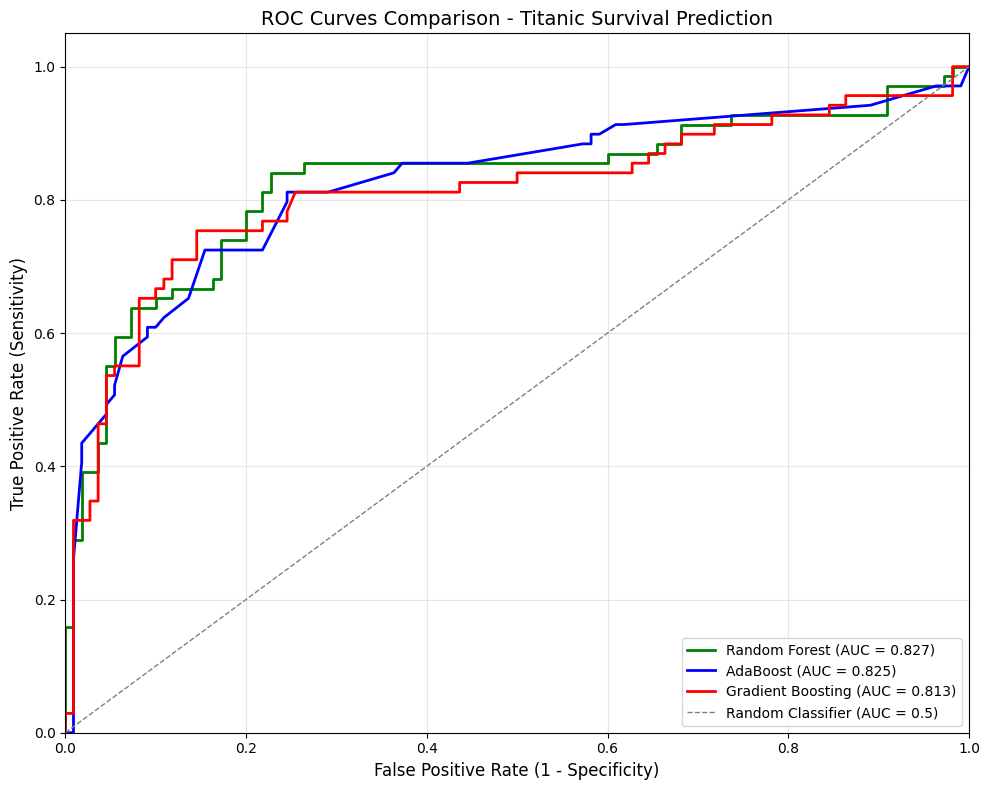


 ROC-кривые сохранены в 'roc_curves_comparison.png'


In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.3f})')
plt.plot(fpr_ada, tpr_ada, color='blue', lw=2, label=f'AdaBoost (AUC = {roc_auc_ada:.3f})')
plt.plot(fpr_gb, tpr_gb, color='red', lw=2, label=f'Gradient Boosting (AUC = {roc_auc_gb:.3f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curves Comparison - Titanic Survival Prediction', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig('roc_curves_comparison.png', dpi=150)
plt.show()

print("\n ROC-кривые сохранены в 'roc_curves_comparison.png'")

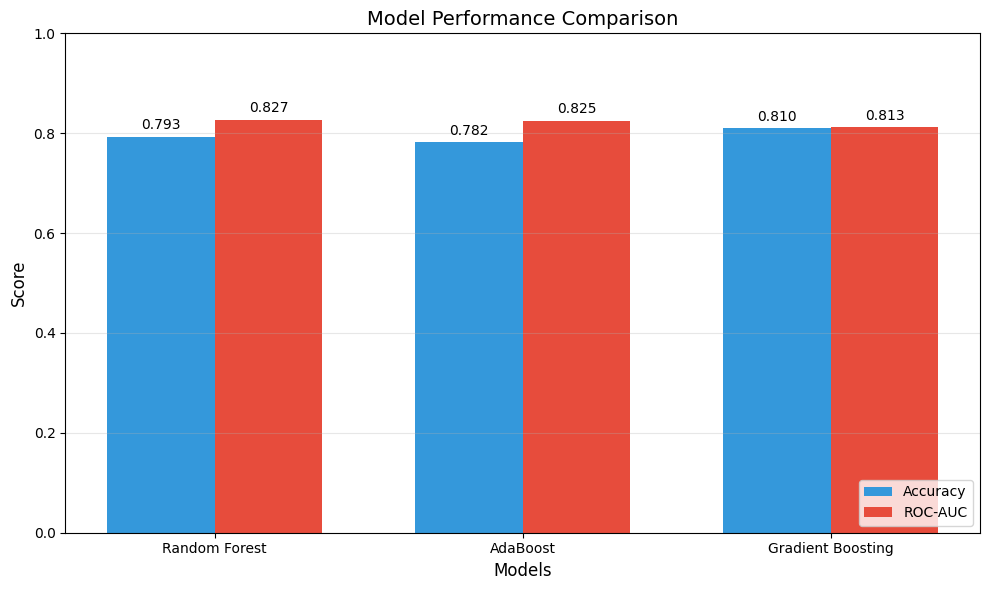

Сравнительная диаграмма сохранена в 'model_comparison.png'


In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

models_names = ['Random Forest', 'AdaBoost', 'Gradient Boosting']
accuracies = [acc_rf, acc_ada, acc_gb]
auc_scores = [roc_auc_rf, roc_auc_ada, roc_auc_gb]

x = np.arange(len(models_names))
width = 0.35

bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='#3498db')
bars2 = ax.bar(x + width/2, auc_scores, width, label='ROC-AUC', color='#e74c3c')

ax.set_xlabel('Models', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models_names)
ax.legend(loc='lower right')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

print("Сравнительная диаграмма сохранена в 'model_comparison.png'")

FEATURE IMPORTANCE - Random Forest
 feature  importance
     Sex    0.356290
    Fare    0.226115
     Age    0.171882
  Pclass    0.122230
   SibSp    0.051402
Embarked    0.036746
   Parch    0.035336


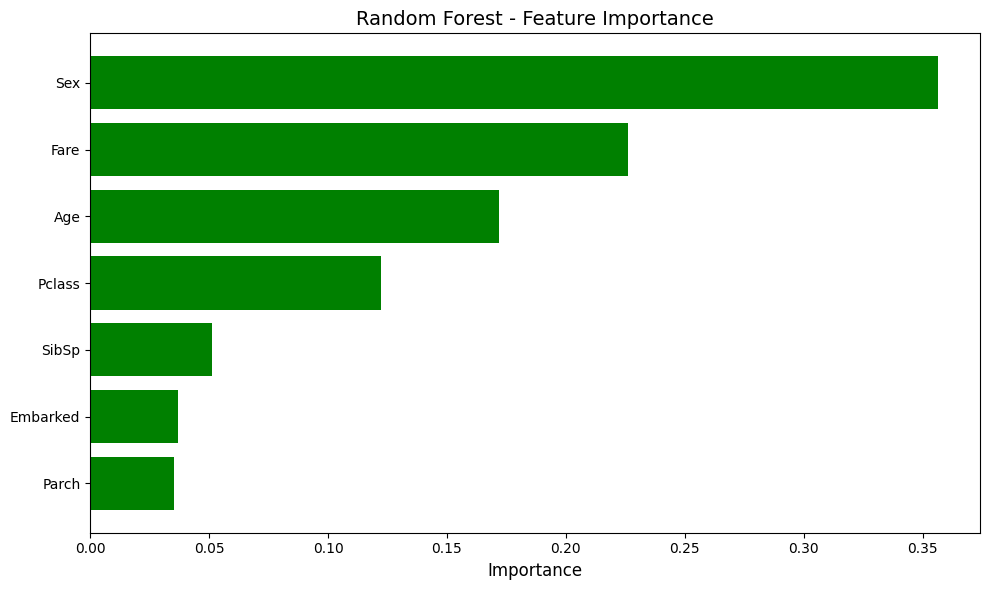

In [24]:
feature_importance_rf = pd.DataFrame({
    'feature': ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked'],
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("FEATURE IMPORTANCE - Random Forest")
print(feature_importance_rf.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_rf['feature'], feature_importance_rf['importance'], color='green')
plt.xlabel('Importance', fontsize=12)
plt.title('Random Forest - Feature Importance', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150)
plt.show()